# 20 · A complete simulated ROS robot

## Learning objectives

- Execute navigation, detection, manipulation, and recovery across nodes.
- Compare final state with the standalone robot.
- Run the same application through installed executables and launch files.

**Environment:** ROS 2 Jazzy, sourced workspace, and the ROS notebook kernel from the README. Every ROS example owns and closes its context; run cells in order. Do not call `rclpy.spin` on nodes already managed by `RosSession`.

## Intuition

We now replace local world operations with ROS service calls while keeping the mission
policy from lesson 14. One node owns the simulated world and publishes telemetry. Another
owns the behavior tree and sends requests. A third observes the telemetry. The graph is:

`robot_tree --Trigger requests--> simulated_robot --String state topic--> observer`

Navigation is an instantaneous relocation to the table; detection, pick, and place are also
short state changes, so services are appropriate here. Real navigation and manipulation take
time and should use the cancellable action pattern from lesson 19, with domain interfaces
such as Nav2's NavigateToPose when those packages are actually needed. We do not require Nav2,
a physics simulator, custom messages, or hardware for this tutorial.

A memory sequence preserves completed mission steps while a service future is RUNNING.
The navigation selector tries the normal route, then clears the obstacle and retries. The
telemetry topic is a JSON string for transparent teaching output, not a proposed production
robot-state schema.

In [1]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display
from behavior_trees_tutorial.ros_nodes.session import RosSession
from uuid import uuid4
import json
from dataclasses import asdict
from time import monotonic, sleep
from std_msgs.msg import String
from behavior_trees_tutorial.simulations.robot import World, mission
from behavior_trees_tutorial.ros_nodes.servers import RobotServer
from behavior_trees_tutorial.ros_nodes.robot_tree import create_mission

## Minimal working example
All three nodes share one context and executor in this notebook. Their service and topic
boundaries are real ROS communication. The launch file later places the controller and
world in separate processes without changing their policy.

Root trace: ['RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'RUNNING', 'SUCCESS']
Observed state: {'location': 'table', 'detected': True, 'holding': False, 'delivered': True, 'blocked': False}


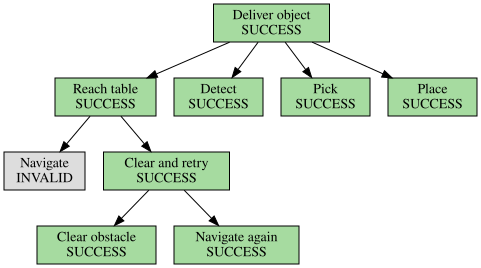

In [2]:
with RosSession() as ros:
    namespace = "/robot_" + uuid4().hex
    server = ros.add(RobotServer(context=ros.context, namespace=namespace))
    controller = ros.node("robot_tree", namespace=namespace)
    observer = ros.node("observer", namespace=namespace)
    observations = []
    subscription = observer.create_subscription(
        String, "robot/state", lambda msg: observations.append(json.loads(msg.data)), 10)
    root = create_mission(controller)
    try:
        statuses = []
        deadline = monotonic() + 8.0
        while monotonic() < deadline:
            root.tick_once()
            statuses.append(root.status.name)
            if root.status is not Status.RUNNING:
                break
            sleep(0.02)
        assert root.status is Status.SUCCESS, statuses
        ros.wait(lambda: bool(observations) and observations[-1]["delivered"])
        final_state = observations[-1]
        assert not final_state["blocked"] and final_state["delivered"]
        print("Root trace:", statuses)
        print("Observed state:", final_state)
        display(diagram(root))
    finally:
        root.stop(Status.INVALID)
        for behavior in root.iterate():
            behavior.shutdown()

## Step-by-step implementation
The adapter makes exactly one asynchronous service request per invocation. Until its reply
arrives it returns RUNNING. A successful Trigger response becomes SUCCESS; a negative reply,
transport exception, or deadline becomes FAILURE. A service timeout cannot undo a request
already executing on the server, so these tiny operations must remain short and safe to repeat.
The model's methods assign state instead of accumulating commands, which makes retry behavior
easy to reason about. This is not enough for non-idempotent hardware operations.

In [3]:
from behavior_trees_tutorial.ros_nodes.adapters import ServiceCall
import inspect
print(inspect.getsource(ServiceCall.update))

local_world = World()
local_tree = mission(local_world)
local_tree.tick_once()
assert local_tree.status is Status.SUCCESS
assert asdict(local_world) == final_state
print("Standalone and ROS final states match.")

    def update(self):
        if monotonic() >= self.deadline:
            return Status.FAILURE
        if self.future is None:
            if not self.client.service_is_ready():
                return Status.RUNNING
            self.future = self.client.call_async(Trigger.Request())
        if not self.future.done():
            return Status.RUNNING
        try:
            return Status.SUCCESS if self.future.result().success else Status.FAILURE
        except Exception:
            return Status.FAILURE

Standalone and ROS final states match.


### Run installed programs
From a sourced workspace terminal (not a notebook shell cell):
```bash
ros2 run behavior_trees_tutorial standalone_robot
ros2 launch behavior_trees_tutorial minimal.launch.py
ros2 launch behavior_trees_tutorial robot.launch.py
```
The robot launch starts the world node and mission node. The mission exits with code 0 on
success and code 1 on failure; its exit shuts down the launch. For manual observation, run
`simulated_robot` and `robot_tree` in separate sourced terminals and use
`ros2 topic echo /robot/state`. Run one copy in the default namespace at a time.
`config/tutorial.yaml` controls the initial obstacle and tick period.

## Interactive demonstration
Explore the equivalent local model after the ROS resources have closed. Choose a different
initial obstacle and compare which navigation branch is active. To repeat distributed
execution, rerun the ROS context cell above.

In [4]:
import ipywidgets as widgets

@widgets.interact(blocked=True)
def explore(blocked=True):
    world = World(blocked=blocked)
    tree = mission(world)
    tree.tick_once()
    display(diagram(tree))
    print(asdict(world))

interactive(children=(Checkbox(value=True, description='blocked'), Output()), _dom_classes=('widget-interact',…

## Key observations

Decision topology and final world state match the standalone model, but ROS needs extra RUNNING ticks while requests travel. Equivalent policy does not imply identical timing.

## Exercises

1. Start the controller without the world node and observe bounded failure.
2. Publish stale telemetry and add a freshness guard.
3. Replace simulated navigation with a real action adapter while retaining the recovery subtree.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 20).

## Summary

The tutorial has moved from a function returning a status to a distributed robot mission. At every stage the same small rules remain visible: requirements, alternatives, progress, and recovery.